# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.


# 1. Problem Statement

Agricultural performance can change with seasonal environmental conditions, farming practices, resource availability and economic factors. The objective is to analyze the supplied agricultural dataset and investigate meaningful **patterns, trends, relationships and variations across seasons**.

## Why this matters

Seasonal analysis can help stakeholders:
- understand variations in agricultural performance
- identify important seasonal trends
- compare performance across periods
- understand changing environmental conditions
- examine differences in resource usage
- identify areas requiring further investigation
- support evidence-based agricultural planning

# 2. Objectives

1. Explore and understand the dataset.
2. Perform appropriate data cleaning and preparation.
3. Examine agricultural performance across Kharif, Rabi and Zaid.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between environmental conditions and agricultural outcomes.
6. Compare crops, irrigation methods and states within seasons.
7. Analyze resource usage and economic outcomes.
8. Identify unusual patterns and outliers.
9. Apply suitable descriptive, comparative and correlation-based techniques.
10. Develop evidence-based conclusions and recommendations.

# 3. Analytical Questions

The following questions were developed from the project brief and the variables available in the dataset:

1. Which season has the highest average yield and profit?
2. How do water, fertilizer and pesticide requirements differ by season?
3. Which environmental variables are associated with yield?
4. Which crops perform best within each season?
5. Does irrigation method affect average yield?
6. Are seasonal yield patterns consistent across states?
7. Does larger cultivated area correspond to higher production?
8. Which season/crop combinations provide stronger economic efficiency?
9. What unusual yield, profit, water-use or risk observations deserve attention?
10. What evidence-based actions could support seasonal agricultural planning?

# 4. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

# 5. Load the Original Dataset

The analysis starts from the **original CSV**, and cleaning is performed within this notebook.

> Keep the CSV file in the same folder as this notebook before running it.

In [11]:
file_path = "/seasonal_agriculture_performance_dataset (2).csv"
df_raw = pd.read_csv(file_path)

print("Original dataset shape:", df_raw.shape)
display(df_raw.head())

Original dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


# 6. Dataset Overview

In [12]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nSeason distribution:")
display(df_raw["Season"].value_counts(dropna=False).to_frame("count"))

Rows: 4000
Columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Season distribution:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


# 7. Initial Data Quality Check

In [13]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

quality = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct,
    "Unique_Values": df_raw.nunique(dropna=True)
})

display(quality[quality["Missing_Count"] > 0])
print("Total missing cells:", int(df_raw.isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))

,Missing_Count,Missing_Percentage,Unique_Values
Rainfall_mm,48,1.20,3256
Soil_Moisture_pct,40,1.00,343
Yield_Tonnes_Ha,32,0.80,738


Total missing cells: 120
Duplicate rows: 0


## Data-cleaning approach

- Duplicate rows are checked before analysis.
- Numeric missing values are imputed with the **median**, which is less sensitive to extreme values.
- Categorical missing values are imputed with the **mode**.
- Original data are retained in `df_raw`; the cleaned working copy is `df`.

In [14]:
df = df_raw.copy()

# Remove exact duplicate rows, if any
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

numeric_imputed = {}
for col in numeric_cols:
    n = df[col].isna().sum()
    if n > 0:
        value = df[col].median()
        df[col] = df[col].fillna(value)
        numeric_imputed[col] = {"count": int(n), "replacement": float(value)}

categorical_imputed = {}
for col in categorical_cols:
    n = df[col].isna().sum()
    if n > 0:
        value = df[col].mode(dropna=True)[0]
        df[col] = df[col].fillna(value)
        categorical_imputed[col] = {"count": int(n), "replacement": str(value)}

print("Duplicates removed:", int(duplicate_count))
print("Remaining missing cells:", int(df.isna().sum().sum()))
print("\nNumeric imputations:")
display(pd.DataFrame(numeric_imputed).T if numeric_imputed else pd.DataFrame())
print("\nCategorical imputations:")
display(pd.DataFrame(categorical_imputed).T if categorical_imputed else pd.DataFrame())

Duplicates removed: 0
Remaining missing cells: 0

Numeric imputations:


,count,replacement
Rainfall_mm,48.00,582.00
Soil_Moisture_pct,40.00,26.40
Yield_Tonnes_Ha,32.00,1.74



Categorical imputations:


""


# 8. Descriptive Statistics

In [15]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",NaN,NaN,NaN,600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


# 9. Seasonal Distribution

In [16]:
season_order = ["Kharif", "Rabi", "Zaid"]
season_counts = df["Season"].value_counts().reindex(season_order)

display(season_counts.to_frame("records"))

,records
Season,
Kharif,1779
Rabi,1627
Zaid,594


# 10. Seasonal Performance — Yield and Profit

In [17]:
season_perf = df.groupby("Season").agg(
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Median_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "median"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Median_Profit_INR=("Profit_INR", "median"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean")
).reindex(season_order)

display(season_perf.round(2))

,Avg_Yield_Tonnes_Ha,Median_Yield_Tonnes_Ha,Avg_Profit_INR,Median_Profit_INR,Avg_Revenue_INR,Avg_Cost_INR
Season,,,,,,
Kharif,5.63,1.94,"178,914.65","38,808.00","710,719.06","531,804.41"
Rabi,5.04,1.67,"87,689.47","-3,187.00","601,526.05","513,836.58"
Zaid,4.64,1.46,"-24,804.82","-62,144.00","519,171.90","543,976.73"


## Plot 1 — Average Yield by Season

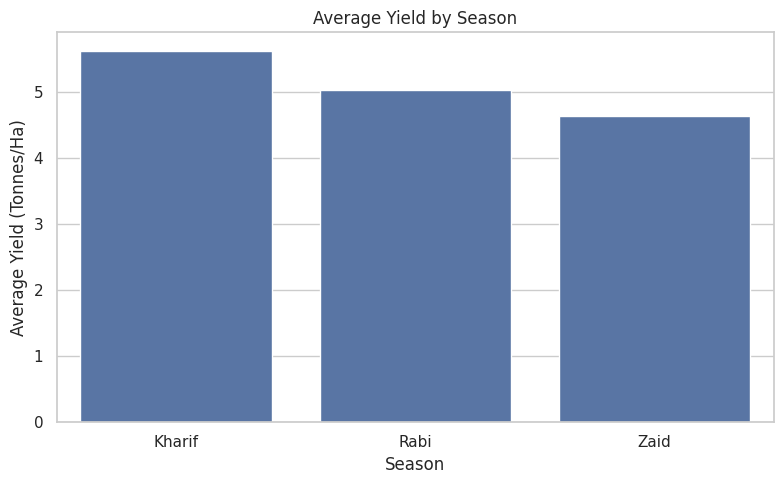

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=season_order, estimator=np.mean, errorbar=None)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## Plot 2 — Average Profit by Season

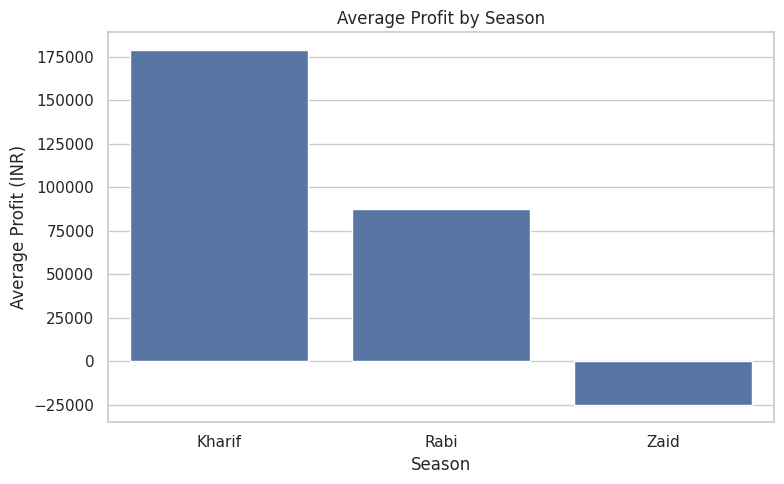

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_INR", order=season_order, estimator=np.mean, errorbar=None)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

### Interpretation

Compare the three seasons using both yield and profit rather than relying on one metric alone. A season can have reasonable production performance but weaker economic performance if costs are high or market returns are lower.

# 11. Seasonal Resource Usage

In [20]:
resource_cols = ["Water_Used_m3", "Fertilizer_kg_ha", "Pesticide_Litre_ha"]
resource_by_season = df.groupby("Season")[resource_cols].mean().reindex(season_order)
display(resource_by_season.round(2))

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,"6,102.20",187.08,5.08
Rabi,"5,846.99",185.41,5.02
Zaid,"6,419.89",184.64,5.17


## Plot 3 — Resource Usage by Season

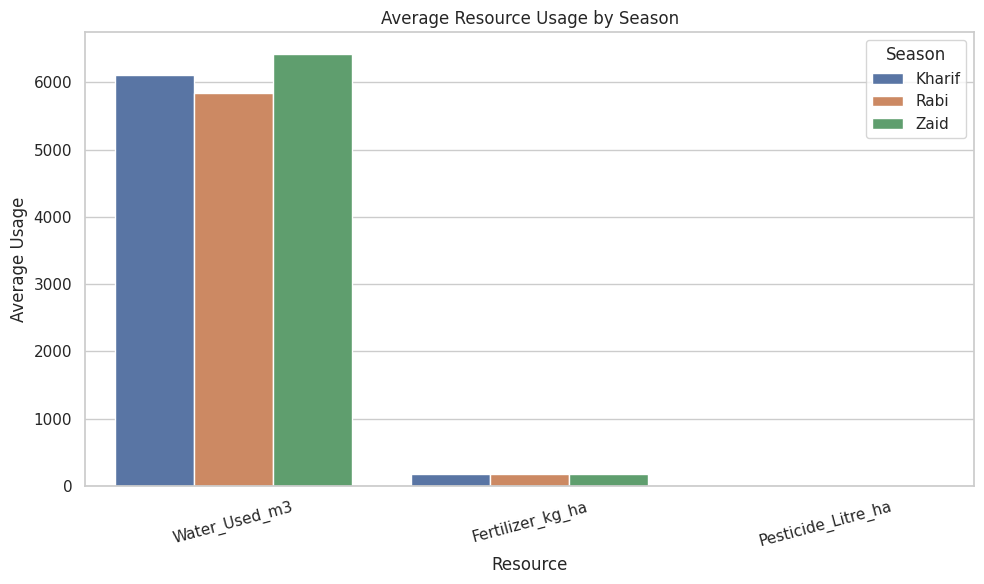

In [21]:
resource_plot = resource_by_season.reset_index().melt(
    id_vars="Season", var_name="Resource", value_name="Average_Usage"
)

plt.figure(figsize=(10,6))
sns.barplot(data=resource_plot, x="Resource", y="Average_Usage", hue="Season")
plt.title("Average Resource Usage by Season")
plt.xlabel("Resource")
plt.ylabel("Average Usage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

This comparison addresses whether resource requirements change with the season. The result should be interpreted alongside yield and profit: higher resource use is not automatically better if it does not translate into stronger agricultural or economic performance.

# 12. Environmental Conditions and Yield

In [22]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

env_corr = df[environment_cols + ["Yield_Tonnes_Ha"]].corr()["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()
display(env_corr.to_frame("Correlation_with_Yield"))

,Correlation_with_Yield
Sunlight_Hours_Day,-0.02
Avg_Temperature_C,0.01
Soil_Moisture_pct,0.01
Humidity_pct,0.01
Rainfall_mm,0.03


## Plot 4 — Environmental Conditions vs Yield

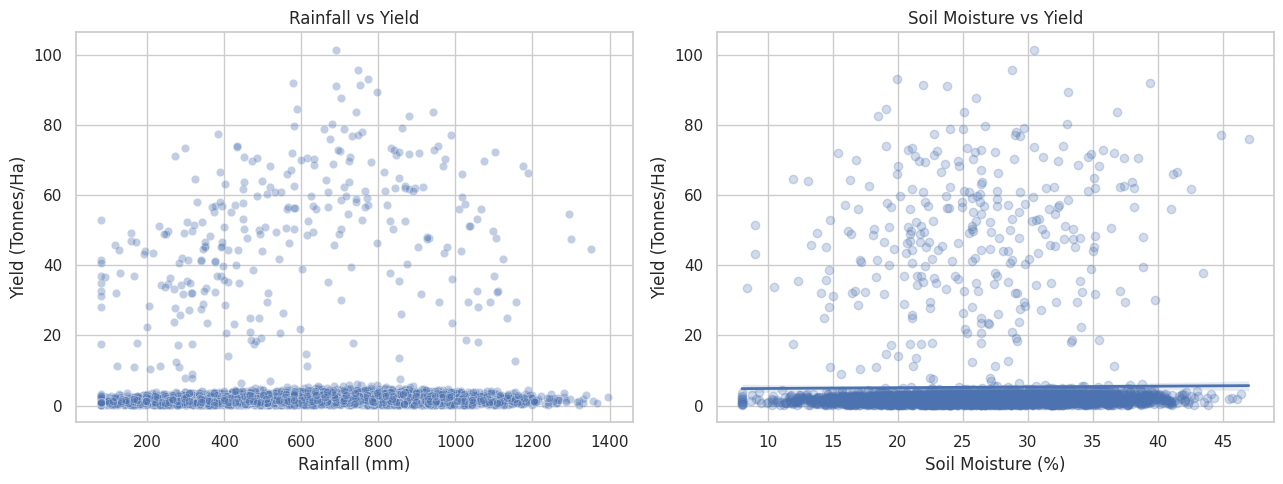

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.35, ax=axes[0])
sns.regplot(data=df, x="Soil_Moisture_pct", y="Yield_Tonnes_Ha",
            scatter_kws={"alpha":0.25}, line_kws={"linewidth":2}, ax=axes[1])

axes[0].set_title("Rainfall vs Yield")
axes[1].set_title("Soil Moisture vs Yield")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Yield (Tonnes/Ha)")
axes[1].set_xlabel("Soil Moisture (%)")
axes[1].set_ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

### Interpretation

Correlation measures association, not causation. Environmental variables should therefore be discussed as relationships observed in this dataset, not as proof that one variable directly causes yield changes.

# 13. Crop × Season Analysis

In [24]:
crop_season = df.pivot_table(
    index="Crop", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
).reindex(columns=season_order)

display(crop_season.round(2))

best_crop_each_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
      .sort_values(["Season", "Yield_Tonnes_Ha"], ascending=[True, False])
      .groupby("Season")
      .head(1)
)

print("Best-performing crop in each season:")
display(best_crop_each_season.sort_values("Season"))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


Best-performing crop in each season:


,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.46
14,Rabi,Sugarcane,43.29
22,Zaid,Sugarcane,38.42


## Plot 5 — Crop Performance Across Seasons

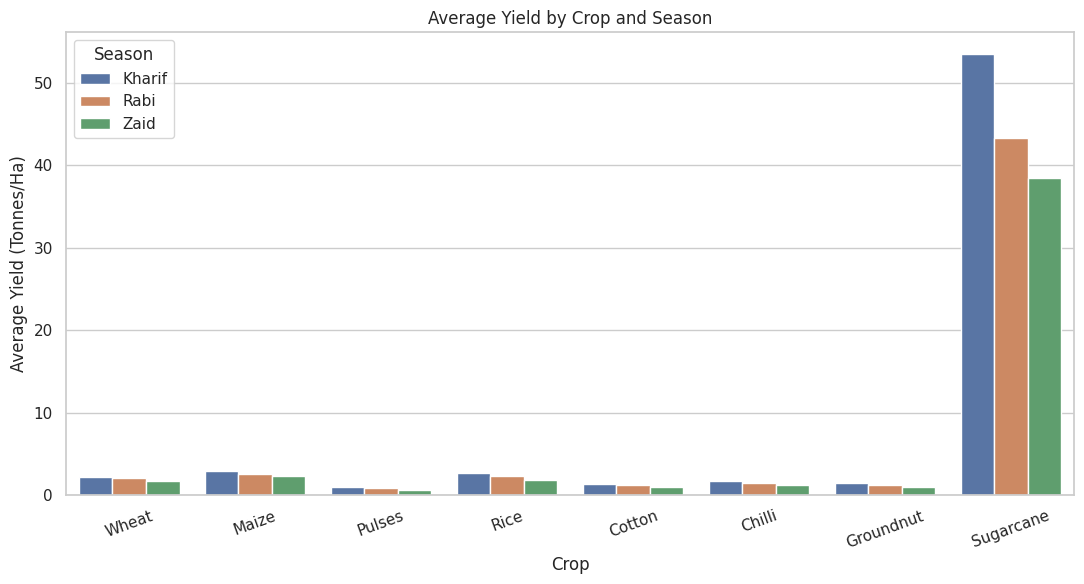

In [25]:
plt.figure(figsize=(11,6))
sns.barplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", hue_order=season_order,
            estimator=np.mean, errorbar=None)
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interpretation

The crop × season analysis is stronger than a single overall crop ranking because it shows whether a crop's performance changes depending on the growing season.

# 14. Irrigation Method Analysis

In [26]:
irrigation = df.groupby("Irrigation_Method").agg(
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean")
).sort_values("Avg_Yield_Tonnes_Ha", ascending=False)

display(irrigation.round(2))

,Avg_Yield_Tonnes_Ha,Avg_Water_Used_m3,Avg_Profit_INR
Irrigation_Method,,,
Drip,6.58,"5,918.75","219,626.00"
Sprinkler,5.16,"6,208.26","91,121.08"
Flood,4.86,"8,026.47","73,354.02"
Rainfed,4.60,"3,549.55","79,050.37"


## Plot 6 — Average Yield by Irrigation Method

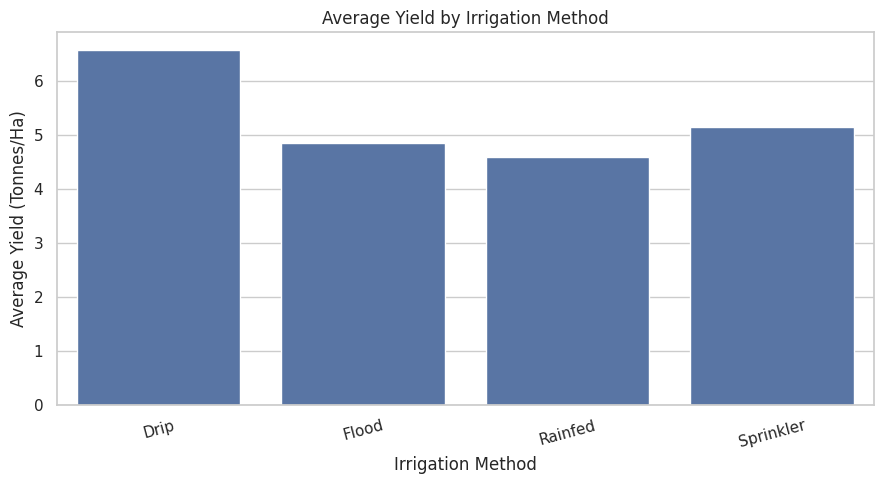

In [27]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha",
            estimator=np.mean, errorbar=None)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 15. State and Regional Analysis

In [28]:
state_perf = df.groupby("State").agg(
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield_Tonnes_Ha", ascending=False)

display(state_perf.round(2))

,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Avg_Water_Efficiency
State,,,
Punjab,6.12,"136,025.64",5.62
Karnataka,5.69,"119,422.34",5.56
Gujarat,5.66,"117,568.24",5.58
Telangana,5.04,"108,829.62",5.46
Maharashtra,5.02,"135,428.86",5.28
Madhya Pradesh,4.99,"86,840.76",5.27
Tamil Nadu,4.88,"117,744.75",5.31
Andhra Pradesh,4.63,"73,453.53",5.03


## Plot 7 — Average Yield by State

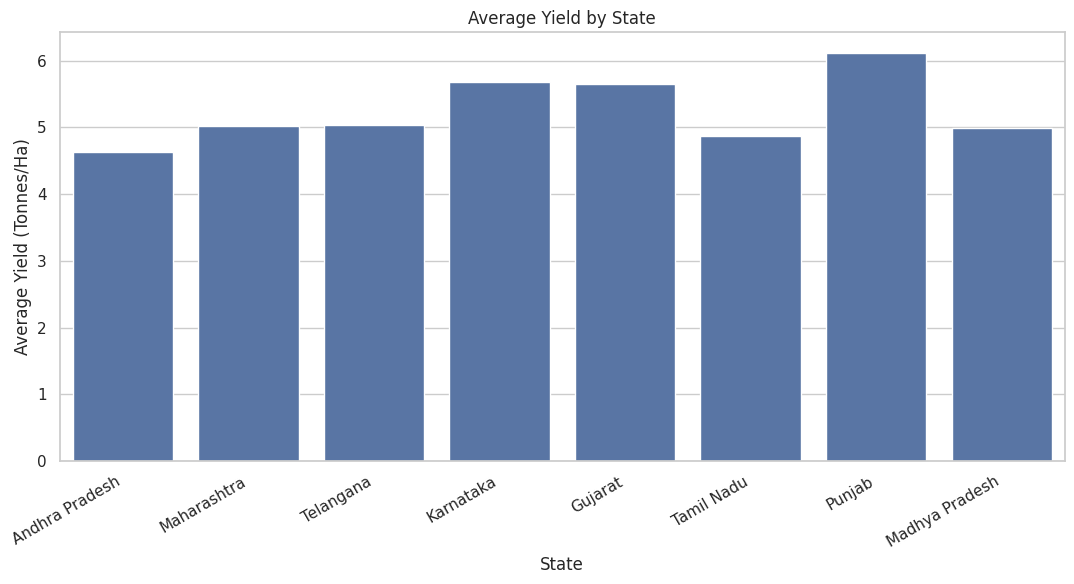

In [29]:
plt.figure(figsize=(11,6))
sns.barplot(data=df, x="State", y="Yield_Tonnes_Ha",
            estimator=np.mean, errorbar=None)
plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 16. Season × State Consistency

In [30]:
state_season = df.pivot_table(
    index="State", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
).reindex(columns=season_order)

display(state_season.round(2))

# Best season in each state
best_season_by_state = state_season.idxmax(axis=1).to_frame("Best_Season")
best_season_by_state["Best_Average_Yield"] = state_season.max(axis=1)
display(best_season_by_state.sort_values("Best_Average_Yield", ascending=False).round(2))

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


,Best_Season,Best_Average_Yield
State,,
Punjab,Rabi,8.61
Karnataka,Zaid,6.62
Gujarat,Kharif,6.34
Madhya Pradesh,Kharif,5.99
Andhra Pradesh,Kharif,5.68
Telangana,Kharif,5.55
Tamil Nadu,Kharif,5.52
Maharashtra,Rabi,5.50


## Plot 8 — State × Season Yield Heatmap

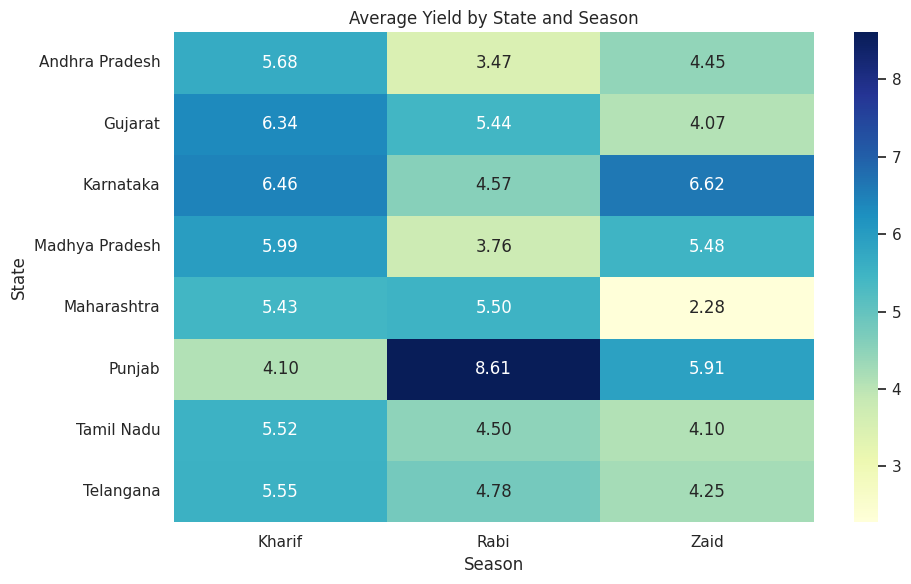

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(state_season, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap checks whether the overall seasonal pattern is consistent across regions. If different states have different best-performing seasons, seasonal planning should be region-specific rather than applying one national pattern uniformly.

# 17. Economic Efficiency

In [32]:
# Derived efficiency indicators
df["Revenue_per_Hectare_INR"] = df["Revenue_INR"] / df["Farm_Area_Hectares"].replace(0, np.nan)
df["Cost_per_Hectare_INR"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"].replace(0, np.nan)
df["Profit_per_Hectare_INR"] = df["Profit_INR"] / df["Farm_Area_Hectares"].replace(0, np.nan)
df["Production_per_Hectare"] = df["Production_Tonnes"] / df["Farm_Area_Hectares"].replace(0, np.nan)

economic_by_season = df.groupby("Season").agg(
    Revenue_per_Hectare_INR=("Revenue_per_Hectare_INR", "mean"),
    Cost_per_Hectare_INR=("Cost_per_Hectare_INR", "mean"),
    Profit_per_Hectare_INR=("Profit_per_Hectare_INR", "mean"),
    Production_per_Hectare=("Production_per_Hectare", "mean")
).reindex(season_order)

display(economic_by_season.round(2))

,Revenue_per_Hectare_INR,Cost_per_Hectare_INR,Profit_per_Hectare_INR,Production_per_Hectare
Season,,,,
Kharif,"88,782.79","66,900.98","21,881.81",5.63
Rabi,"76,656.92","66,295.24","10,361.68",5.09
Zaid,"64,301.42","66,937.94","-2,636.52",4.63


## Plot 9 — Profit per Hectare by Season

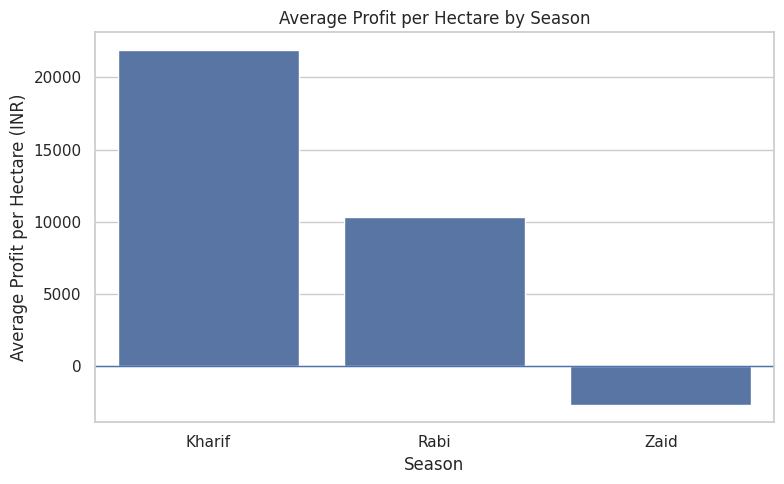

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_per_Hectare_INR",
            order=season_order, estimator=np.mean, errorbar=None)
plt.axhline(0, linewidth=1)
plt.title("Average Profit per Hectare by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit per Hectare (INR)")
plt.tight_layout()
plt.show()

### Interpretation

Per-hectare metrics are useful because total profit alone can be influenced by farm size. Profit per hectare gives a more comparable view of economic efficiency across farms and seasons.

# 18. Area vs Production

In [34]:
area_prod_corr = df[["Farm_Area_Hectares", "Production_Tonnes"]].corr().iloc[0,1]
print(f"Pearson correlation between farm area and production: {area_prod_corr:.3f}")

Pearson correlation between farm area and production: 0.198


## Plot 10 — Farm Area vs Production

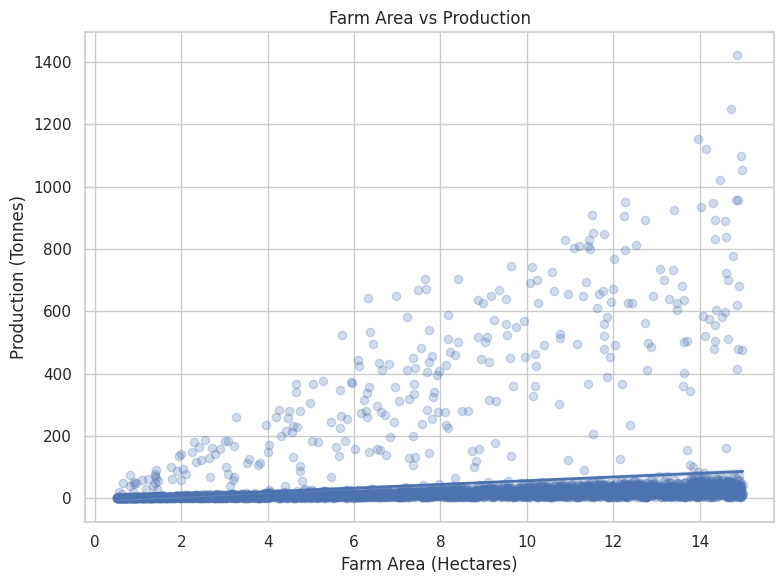

In [35]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes",
            scatter_kws={"alpha":0.25}, line_kws={"linewidth":2})
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

### Interpretation

A positive relationship would indicate that larger cultivated area generally corresponds to greater total production. This does not mean that area alone determines productivity; yield per hectare remains important.

# 19. Water Efficiency vs Yield

In [36]:
water_corr = df[["Water_Efficiency_t_per_1000m3", "Yield_Tonnes_Ha"]].corr().iloc[0,1]
print(f"Pearson correlation between water efficiency and yield: {water_corr:.3f}")

Pearson correlation between water efficiency and yield: 0.913


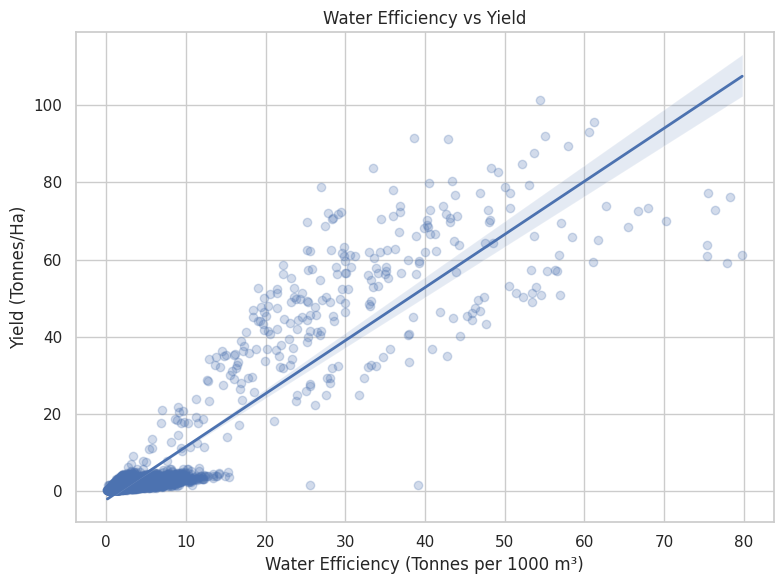

In [37]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,
            x="Water_Efficiency_t_per_1000m3",
            y="Yield_Tonnes_Ha",
            scatter_kws={"alpha":0.25},
            line_kws={"linewidth":2})
plt.title("Water Efficiency vs Yield")
plt.xlabel("Water Efficiency (Tonnes per 1000 m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

### Interpretation

Water efficiency is examined as an indicator of how much yield is associated with a given quantity of water used. A strong positive association in this dataset would support resource-efficient agricultural planning, while still not establishing causation.

# 20. Correlation Analysis

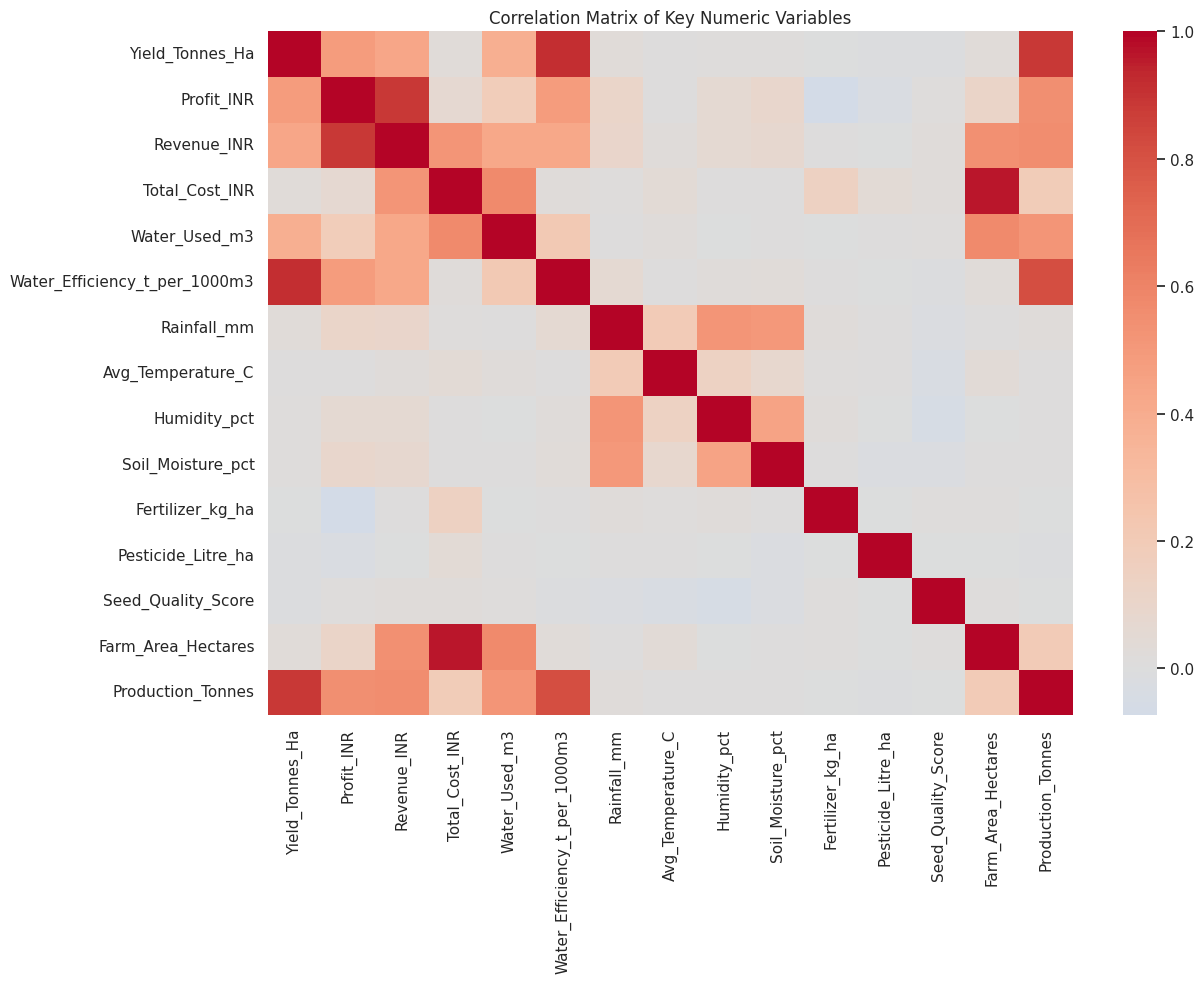

Variables most positively associated with yield:


,Correlation
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Rainfall_mm,0.03
Total_Cost_INR,0.03


In [38]:
key_numeric = [
    "Yield_Tonnes_Ha", "Profit_INR", "Revenue_INR", "Total_Cost_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Soil_Moisture_pct", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Farm_Area_Hectares", "Production_Tonnes"
]

corr = df[key_numeric].corr()

plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.show()

print("Variables most positively associated with yield:")
display(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).head(8).to_frame("Correlation"))

# 21. Statistical Test — Seasonal Yield Differences

In [39]:
season_groups = [
    df.loc[df["Season"] == season, "Yield_Tonnes_Ha"]
    for season in season_order
]

anova_result = stats.f_oneway(*season_groups)

print(f"One-way ANOVA F-statistic: {anova_result.statistic:.3f}")
print(f"One-way ANOVA p-value: {anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    print("Conclusion: There is evidence of a statistically significant difference in mean yield among seasons at the 5% level.")
else:
    print("Conclusion: The observed differences in mean yield are not statistically significant at the 5% level.")

One-way ANOVA F-statistic: 1.544
One-way ANOVA p-value: 0.2137
Conclusion: The observed differences in mean yield are not statistically significant at the 5% level.


### Statistical interpretation

The ANOVA tests whether the mean yield differs across the three seasons. The test result should be interpreted together with descriptive statistics and visualizations. Statistical significance does not by itself establish a causal explanation for the seasonal differences.

# 22. Unusual Patterns and Outliers

Outliers are **identified rather than automatically deleted**. An unusual observation may represent a genuine farming condition and can be useful for investigation.

The analysis checks:
- unusually high/low yield
- unusually high water use
- unusually low or negative profit
- unusually high disease/pest risk

In [40]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_summary = {}
for col in ["Yield_Tonnes_Ha", "Water_Used_m3", "Profit_INR", "Disease_Pest_Risk_pct"]:
    low, high = iqr_bounds(df[col])
    mask = (df[col] < low) | (df[col] > high)
    outlier_summary[col] = {
        "Lower_Bound": low,
        "Upper_Bound": high,
        "Outlier_Count": int(mask.sum())
    }

display(pd.DataFrame(outlier_summary).T)

,Lower_Bound,Upper_Bound,Outlier_Count
Yield_Tonnes_Ha,-1.62,5.50,302.00
Water_Used_m3,"-6,072.75","16,171.25",276.00
Profit_INR,"-696,111.00","763,567.00",404.00
Disease_Pest_Risk_pct,10.90,81.30,10.00


In [41]:
yield_low, yield_high = iqr_bounds(df["Yield_Tonnes_Ha"])
water_low, water_high = iqr_bounds(df["Water_Used_m3"])

unusual = df[
    (df["Yield_Tonnes_Ha"] < yield_low) |
    (df["Yield_Tonnes_Ha"] > yield_high) |
    (df["Water_Used_m3"] > water_high) |
    (df["Profit_INR"] < 0)
].copy()

cols = [
    "Farm_ID","State","District","Crop","Season",
    "Yield_Tonnes_Ha","Production_Tonnes","Profit_INR",
    "Water_Used_m3","Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

print("Number of observations flagged for further investigation:", len(unusual))
display(unusual[cols].head(20))

Number of observations flagged for further investigation: 2297


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,2.46,1.30,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,0.30,1.96,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,0.52,2.53,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,1.84,8.28,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,2.21,9.30,-144352,3287,2.83,32.30
5,SF10006,Gujarat,Raichur,Pulses,Zaid,0.72,3.93,-32763,1093,3.60,57.10
6,SF10007,Telangana,Warangal,Wheat,Rabi,2.53,20.57,-41239,2368,8.69,31.60
10,SF10011,Maharashtra,Krishna,Wheat,Rabi,1.44,6.77,-148902,2371,2.85,33.50
11,SF10012,Telangana,Rajkot,Maize,Rabi,1.36,19.14,-579415,7467,2.56,35.00
12,SF10013,Punjab,Indore,Wheat,Rabi,0.30,1.81,-293090,1411,1.28,49.60


# 23. Significant Observations

In [42]:
best_season_yield = season_perf["Avg_Yield_Tonnes_Ha"].idxmax()
best_season_profit = season_perf["Avg_Profit_INR"].idxmax()
worst_season_profit = season_perf["Avg_Profit_INR"].idxmin()
best_irrigation = irrigation["Avg_Yield_Tonnes_Ha"].idxmax()
best_state = state_perf["Avg_Yield_Tonnes_Ha"].idxmax()

print(f"Highest average yield season: {best_season_yield}")
print(f"Highest average profit season: {best_season_profit}")
print(f"Lowest average profit season: {worst_season_profit}")
print(f"Highest average-yield irrigation method: {best_irrigation}")
print(f"Highest average-yield state: {best_state}")
print(f"Water-efficiency/yield correlation: {water_corr:.3f}")
print(f"Area/production correlation: {area_prod_corr:.3f}")

Highest average yield season: Kharif
Highest average profit season: Kharif
Lowest average profit season: Zaid
Highest average-yield irrigation method: Drip
Highest average-yield state: Punjab
Water-efficiency/yield correlation: 0.913
Area/production correlation: 0.198


# 24. Evidence-Based Insights

In [43]:
# Automatically generate concise evidence statements from the calculated results.
top_crop = (
    df.groupby("Crop")["Yield_Tonnes_Ha"].mean()
      .sort_values(ascending=False).index[0]
)
top_crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().max()

print("Evidence-based insights:")
print(f"1. {best_season_yield} has the highest average yield among the three seasons.")
print(f"2. {best_season_profit} has the highest average profit among the three seasons, while {worst_season_profit} has the lowest.")
print(f"3. {top_crop} has the highest average yield among the crops in the dataset ({top_crop_yield:.2f} Tonnes/Ha).")
print(f"4. {best_irrigation} has the highest average yield among the irrigation methods.")
print(f"5. Water efficiency has a correlation of {water_corr:.3f} with yield in this dataset.")
print(f"6. Farm area and total production have a correlation of {area_prod_corr:.3f}.")

Evidence-based insights:
1. Kharif has the highest average yield among the three seasons.
2. Kharif has the highest average profit among the three seasons, while Zaid has the lowest.
3. Sugarcane has the highest average yield among the crops in the dataset (46.64 Tonnes/Ha).
4. Drip has the highest average yield among the irrigation methods.
5. Water efficiency has a correlation of 0.913 with yield in this dataset.
6. Farm area and total production have a correlation of 0.198.


# 25. Recommendations for Seasonal Agricultural Planning

The recommendations below should be refined after reviewing the executed tables and charts:

1. **Plan season-specific resource allocation.** Water, fertilizer and pesticide requirements should be compared before planning seasonal inputs.
2. **Use crop × season evidence.** Crop selection should consider the season in which each crop demonstrates stronger yield performance.
3. **Adopt region-specific planning.** The State × Season analysis can reveal where a season performs differently from the overall dataset.
4. **Prioritize resource efficiency.** Where higher water efficiency is associated with stronger yield, efficient irrigation and water-management practices deserve attention.
5. **Use economic efficiency metrics.** Profit per hectare should complement total profit when comparing farms of different sizes.
6. **Investigate unusual observations.** Extreme yield, water-use, profit and risk records should be examined for possible operational explanations rather than removed automatically.
7. **Balance environmental and production indicators.** Rainfall, temperature, humidity and soil moisture should be considered alongside farming practices and resource use.
8. **Treat correlations as evidence of association, not causation.** Further field-level or longitudinal studies would be needed to establish causal effects.

# 26. Limitations

- The dataset represents the available observations and may not capture every agricultural condition.
- Missing values were imputed, so imputed observations may introduce some uncertainty.
- The analysis is primarily descriptive and correlational.
- Observational relationships do not establish causation.
- State-level patterns may reflect differences in crop mix, farming practices and other factors.
- Further analysis with multi-year time-series data could strengthen seasonal planning conclusions.

# 27. Learning Outcomes

This project demonstrates:

- **Understanding of seasonal agricultural data** through dataset exploration and seasonal comparisons.
- **Data cleaning and preparation** through duplicate checks and missing-value treatment.
- **Identification of seasonal patterns** using grouped summaries and visualizations.
- **Agricultural performance comparison** across seasons, crops, irrigation methods and states.
- **Relationships and variations** through correlation, scatter plots and a State × Season heatmap.
- **Selection of analytical techniques** including descriptive statistics, grouped analysis, correlation and ANOVA.
- **Correct interpretation** through written explanations after major analyses.
- **Identification of significant observations** through comparative metrics and outlier analysis.
- **Evidence-based insights** derived directly from computed results.
- **Appropriate recommendations** for seasonal agricultural planning.

# 28. Conclusion

The Seasonal Agriculture Performance Analysis provides a structured view of how agricultural outcomes vary across Kharif, Rabi and Zaid seasons. The project combines data preparation, descriptive analysis, seasonal comparison, environmental analysis, crop and regional comparisons, economic efficiency, relationship analysis and outlier investigation.

The strongest conclusions should be based on the executed tables and visualizations rather than a single metric. In particular, seasonal yield and profitability, resource requirements, crop suitability, regional consistency and water efficiency together provide a more complete basis for seasonal agricultural planning.

Overall, the analysis demonstrates how data analytics can transform raw agricultural observations into measurable patterns, evidence-based insights and practical planning recommendations.

# 29. Project Details

**Student Name:** Aman Kumar

**College Name:** Chandigarh University

**AICTE STU ID:** STU6a641a16ab1121784945174

**GitHub Repository:**  
